# Figure 2: Dual occluder task

In [99]:
%load_ext autoreload
%autoreload 2

2025-06-06 11:28:20,375::INFO::table.py::could not log event in table ~log
2025-06-06 11:28:20,375::INFO::table.py::could not log event in table ~log
2025-06-06 11:28:22,280::INFO::table.py::could not log event in table ~log
2025-06-06 11:28:22,280::INFO::table.py::could not log event in table ~log


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [100]:
cd "/app/"

/app


In [101]:
%run env_aws.py
%run run.py connect

2025-06-06 11:28:22,722::INFO::settings.py::Setting loglevel to INFO
2025-06-06 11:28:22,722::INFO::settings.py::Setting loglevel to INFO
2025-06-06 11:28:22,726::INFO::settings.py::Setting stores to {}
2025-06-06 11:28:22,726::INFO::settings.py::Setting stores to {}
2025-06-06 11:28:22,728::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-06-06 11:28:22,728::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-06-06 11:28:22,731::INFO::settings.py::Setting database.misc.create_tables to True
2025-06-06 11:28:22,731::INFO::settings.py::Setting database.misc.create_tables to True
2025-06-06 11:28:22,733::INFO::settings.py::Setting enable_python_native_blobs to True
2025-06-06 11:28:22,733::INFO::settings.py::Setting enable_python_native_blobs to True
2025-06-06 11:28:22,736::INFO::settings.py::Setting database.host to vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com
2025-06-06 11:28:22,736::INFO::settings.py::Setting database.host to vr4mic

In [203]:
from vr4mice.schema.base_analysis import DataFrame
from vr4mice.schema.vr4mice import Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema.interpolated_trajectories import InterpolatedTrials, MeanXYTrajectory, MeanVelocities,YBinnedXYTrajectory
from vr4mice.schema.session_metrics import TrialMetrics, SessionMetrics
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils

from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats


style()

save_fig_path = "notebooks/Paper_figures/Figure_output/Figure2/"

## Example trajectories (Pheasant_2024-08-15_2)

In [103]:
# Load dataset and box positions
df = DataFrame().get_data(
    key={"dataset": "Pheasant_2024-08-15_2"},
    columns=[
        "dataset",
        "reward",
        "x",
        "y",
        "trial",
        "aperture",
        "iti",
        "trial_left_choice",
        "trial_duration",
        "trial_tortuosity",
    ],
)
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

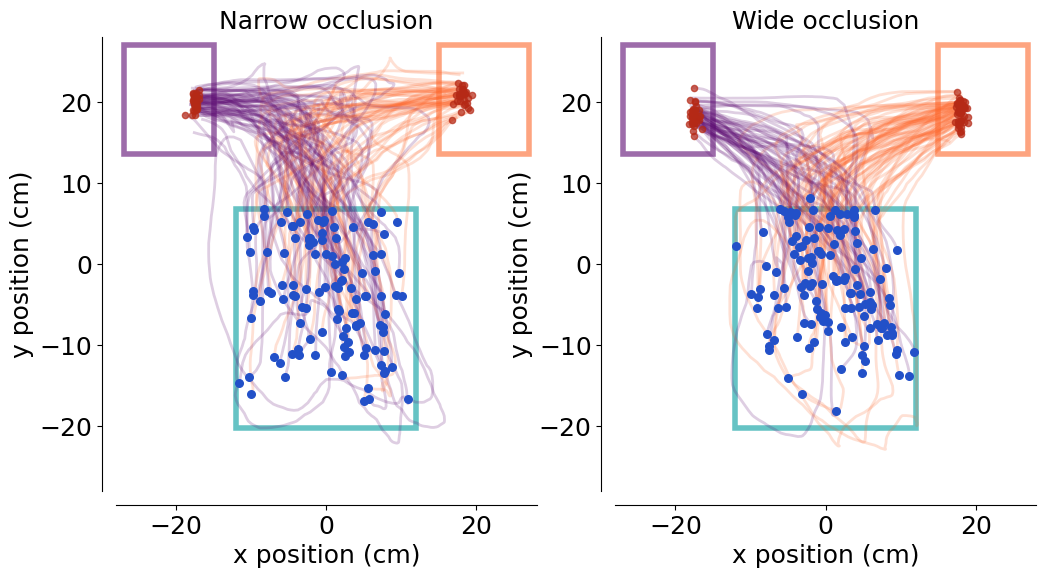

In [104]:
df = df[df.iti == 0.0]
j_shaped = analysis.get_jshaped_trials(df)

ax = plotting.plot_session(
    df=j_shaped,
    box_df=box_df,
    per_aperture=True,
    per_side=True,
)

ax[0].set_title("Narrow occlusion")
ax[1].set_title("Wide occlusion")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure2_example_session_trajectory_plot_dual_occluder.svg", transparent=True)

In [256]:
len(InterpolatedTrials() * vr4mice.Groups() * vr4mice.Labels() * (vr4mice.Dataset()))

115

## Combined sessions analysis
Fetching the data:

In [246]:
trial_df = (TrialMetrics() * vr4mice.Groups() * vr4mice.Labels() * (vr4mice.Dataset() & 'session_label = "ar_discrim_occluders"')).fetch(as_dict=True)
trial_df =  pd.concat([pd.DataFrame(x) for x in trial_df])
# Exclude sessions that were not in the list
trial_df, reward_table = utils.dual_occluder_inclusion_criteria(trial_df, return_excluded=False)
# Create list of included datasets
mouse_list = trial_df.dataset.unique()
trial_df["mouse_name"] = trial_df.dataset.str.split("_").str [0]

Excluded datasets:  []


In [247]:
mouse_list

array(['31726_2025-03-18_1', '31726_2025-03-19_1', '31726_2025-03-20_1',
       '31726_2025-03-21_1', 'Jacana_2024-08-13_1', 'Jacana_2024-08-14_1',
       'Jacana_2024-08-15_1', 'Jacana_2024-08-16_1',
       'Jacana_2024-08-19_1', 'Kiwi_2024-08-10_2', 'Kiwi_2024-08-11_4',
       'Kiwi_2024-08-12_2', 'Kiwi_2024-08-13_1', 'Kiwi_2024-08-14_1',
       'Lemming_2024-08-10_1', 'Lemming_2024-08-11_1',
       'Lemming_2024-08-12_1', 'Lemming_2024-08-13_1',
       'Nightingale_2024-08-10_1', 'Nightingale_2024-08-11_1',
       'Nightingale_2024-08-12_1', 'Nightingale_2024-08-13_1',
       'Nightingale_2024-08-14_1', 'Oribi_2024-08-16_1',
       'Oribi_2024-08-19_1', 'Oribi_2024-08-20_1', 'Oribi_2024-08-21_1',
       'Oribi_2024-08-22_1', 'Pheasant_2024-08-15_2',
       'Pheasant_2024-08-16_1', 'Pheasant_2024-08-19_1',
       'Pheasant_2024-08-20_1', 'Pheasant_2024-08-21_1'], dtype=object)

2025-06-06 11:28:32,395::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-06 11:28:32,395::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-06 11:28:32,412::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-06 11:28:32,412::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-06 11:28:32,475::INFO::category.py::Using categorical un

12.0-4.3: TtestResult(statistic=3.1709445462603454, pvalue=0.003664517151297114, df=28)
              mean       sem
aperture                    
12.0      0.861096  0.013598
4.3       0.792184  0.015618


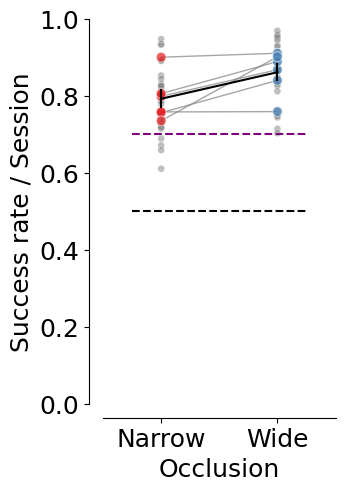

In [106]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
)

ax.hlines(
    0.7,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="purple",
)
ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)
plt.ylim(0, 1.0)
plt.xlim(-0.5, 1.5)
ax.set_ylabel("Success rate / Session")
ax.set_xlabel("Occlusion")
ax.set_xticks([0, 1], ["Narrow", "Wide"])
sns.despine(offset=10)
plt.legend([], [], frameon=False)
plt.savefig(save_fig_path + "Figure2_trial_reward.svg", transparent=True)

2025-06-06 11:28:32,780::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-06 11:28:32,780::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-06 11:28:32,785::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2025-06-06 11:28:32,785::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-06 11:28:32,822::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-06 11:28:32,822::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-06 11:28:32,832::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-06 11:28:32,832::INFO::category.py::Using categorical un

wide occlusion mean:  0.5019791488563901 std:  0.03263368363436238
narrow occlusion mean:  0.49802085114360994 std:  0.032633683634362386


TtestResult(statistic=0.3209160044728908, pvalue=0.7506571060987997, df=28)

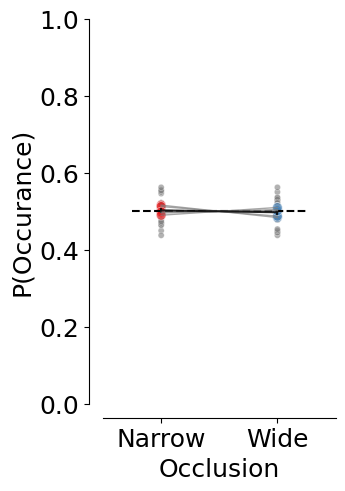

In [107]:
# Occurance of the different conditions
counts = (
    trial_df.groupby(["dataset", "mouse_name", "aperture"])
    .trial.nunique()
    .reset_index(name="trial_count")
)
total_trials = (
    trial_df.groupby("dataset").trial.nunique().reset_index(name="total_trials")
)

counts = counts.merge(total_trials, on="dataset")
counts["probability"] = counts["trial_count"] / counts["total_trials"]
counts.sort_values("aperture", inplace=True)
counts["aperture"] = counts.aperture.astype("str")

fig, ax = plt.subplots(1, 1, figsize=(3, 5))

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    units="mouse_name",
    estimator=None,
    ax=ax,
    color="grey",
    alpha=0.7,
    linewidth=1,
    zorder=3,
)

sns.scatterplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    hue="aperture",
    ax=ax,
    palette=plotting.colors_aperture,
    alpha=0.6,
    s=50,
    zorder=2,
)

sns.scatterplot(
    data=counts,
    x="aperture",
    y="probability",
    hue="aperture",
    ax=ax,
    palette=["grey"] * counts["dataset"].nunique(),
    alpha=0.6,
    zorder=1,
    s=20,
)

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    ax=ax,
    color="black",
    err_style="bars",
    errorbar="se",
    alpha=0.8,
    zorder=4,
)

ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

plt.ylim(0, 1)
plt.xlim(-0.5, 1.5)
plt.xticks([0, 1], ["Narrow", "Wide"])

plt.xlabel("Occlusion")
plt.ylabel("P(Occurance)")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(save_fig_path + "figure2_dual_occluder_trial_number.svg", transparent=True)

counts = counts.pivot(index="dataset", columns=["aperture"], values=["probability"])
print(
    "wide occlusion mean: ",
    np.mean(np.array(counts["probability"]["12.0"])),
    "std: ",
    np.std(np.array(counts["probability"]["12.0"])),
)
print(
    "narrow occlusion mean: ",
    np.mean(np.array(counts["probability"]["4.3"])),
    "std: ",
    np.std(np.array(counts["probability"]["4.3"])),
)
ttest_rel(
    np.array(counts["probability"]["12.0"]), np.array(counts["probability"]["4.3"])
)

2025-06-06 11:28:33,091::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-06 11:28:33,091::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-06 11:28:33,098::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2025-06-06 11:28:33,098::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-06 11:28:33,180::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-06 11:28:33,180::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-06 11:28:33,189::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-06 11:28:33,189::INFO::category.py::Using categorical un

12.0-4.3: TtestResult(statistic=-0.24686509080784402, pvalue=0.8068136802669097, df=28)
              mean       sem
aperture                    
12.0      0.545032  0.022306
4.3       0.554283  0.026774


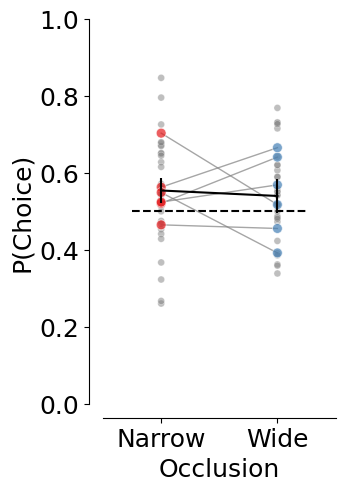

In [108]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_left_choice",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
)

ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_xlabel("Occlusion")
ax.set_ylim(0, 1)
plt.legend([], [], frameon=False)
plt.ylabel("P(Choice)")
ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

sns.despine(offset=10)

plt.savefig(save_fig_path + "figure2_dual_occluder_choice_proba.svg", transparent=True)

## Trajectory analysis

In [169]:
xy_df = []
for m in mouse_list:
    print(m)
    xy_df.append(pd.DataFrame((MeanXYTrajectory() & f'dataset="{m}"').fetch(as_dict=True)[0]))
xy_df = pd.concat(xy_df)
xy_df ["mouse_name"] = xy_df.dataset.str.split("_").str [0]

    

Jacana_2024-08-13_1
Jacana_2024-08-14_1
Jacana_2024-08-15_1
Jacana_2024-08-16_1
Jacana_2024-08-19_1
Kiwi_2024-08-10_2
Kiwi_2024-08-11_4
Kiwi_2024-08-12_2
Kiwi_2024-08-13_1
Kiwi_2024-08-14_1
Lemming_2024-08-10_1
Lemming_2024-08-11_1
Lemming_2024-08-12_1
Lemming_2024-08-13_1
Nightingale_2024-08-10_1
Nightingale_2024-08-11_1
Nightingale_2024-08-12_1
Nightingale_2024-08-13_1
Nightingale_2024-08-14_1
Oribi_2024-08-16_1
Oribi_2024-08-19_1
Oribi_2024-08-20_1
Oribi_2024-08-21_1
Oribi_2024-08-22_1
Pheasant_2024-08-15_2
Pheasant_2024-08-16_1
Pheasant_2024-08-19_1
Pheasant_2024-08-20_1
Pheasant_2024-08-21_1


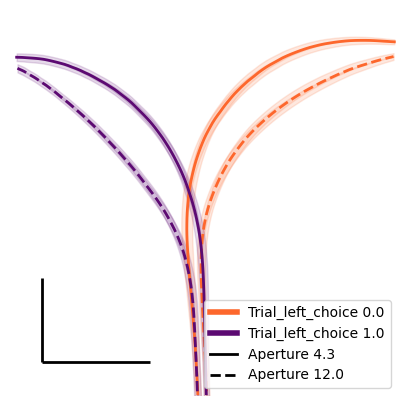

In [110]:
# mean and error by mouse
mean_mouse = analysis.mean_xy_trajectory(xy_df, index_columns= ["dataset", "mouse_name", "aperture", "trial_left_choice", "trial_length"])
# mean and error by whole group
mean_group = analysis.mean_xy_trajectory(mean_mouse, index_columns= ["aperture",  "trial_left_choice", "trial_length"])
# plot_mean_trajectories
plotting.plot_mean_xy_trajectory(mean_group,cmap = plotting.colors_choice [::-1],color_by="choice", style_by="aperture")
plt.savefig("figure_2_dual_occluder_mean_xy_trajectories.svg", transparent=True)

In [ ]:
# currently takes 1.1 mins
y_binned_df = []
for m in mouse_list:
    try:
        print(m)
        y_binned_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch("dataset", "aperture", "trial", "x", "y", "flip_one_side", as_dict=True)[0]))
    except Exception as err:
        print(err)
y_binned_df = pd.concat(y_binned_df)

y_binned_df ["mouse_name"] = y_binned_df.dataset.str.split("_").str [0]
y_binned_df ["x_flipped"] = y_binned_df.x * y_binned_df.flip_one_side
data = utils.create_bins(y_binned_df)
y_binned_df = analysis.mean_xy_trajectory(data, index_columns= ["dataset", "mouse_name", "aperture", "bin_centers"], values=["x_flipped", "y"])


31726_2025-03-18_1
list index out of range
31726_2025-03-19_1
list index out of range
31726_2025-03-20_1
list index out of range
31726_2025-03-21_1
list index out of range
Jacana_2024-08-13_1
Jacana_2024-08-14_1
Jacana_2024-08-15_1
Jacana_2024-08-16_1
Jacana_2024-08-19_1
Kiwi_2024-08-10_2
Kiwi_2024-08-11_4
Kiwi_2024-08-12_2
Kiwi_2024-08-13_1
Kiwi_2024-08-14_1
Lemming_2024-08-10_1
Lemming_2024-08-11_1
Lemming_2024-08-12_1
Lemming_2024-08-13_1
Nightingale_2024-08-10_1
Nightingale_2024-08-11_1
Nightingale_2024-08-12_1
Nightingale_2024-08-13_1
Nightingale_2024-08-14_1
Oribi_2024-08-16_1
Oribi_2024-08-19_1
Oribi_2024-08-20_1
Oribi_2024-08-21_1
Oribi_2024-08-22_1
Pheasant_2024-08-15_2
Pheasant_2024-08-16_1
Pheasant_2024-08-19_1
Pheasant_2024-08-20_1
Pheasant_2024-08-21_1


Text(0, 0.5, 'X position')

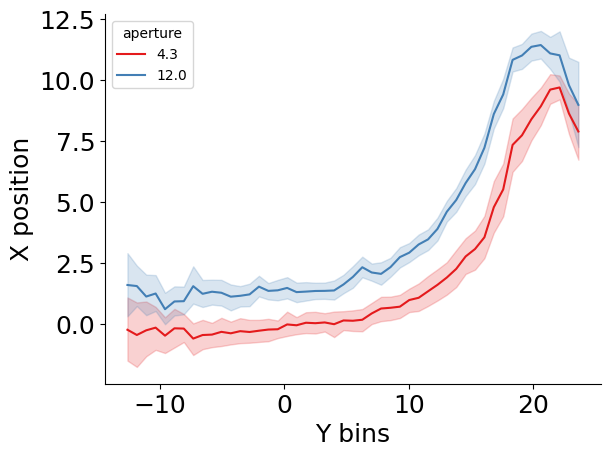

In [260]:
sns.lineplot(data = dfp, x="bin_centers", y="x_flipped", hue="aperture", palette= plotting.colors_aperture)
plt.xlabel("Y bins")
plt.ylabel("X position")

In [265]:
stats_binned = dfp [(dfp.bin_centers > -10) & (dfp.bin_centers < 19)]
print(
    AnovaRM(
        data=stats_binned,
        depvar="x_flipped",
        subject="dataset",
        within=["aperture", "bin_centers"],
    ).fit()
)

                        Anova
                     F Value   Num DF   Den DF  Pr > F
------------------------------------------------------
aperture              67.3276  1.0000   28.0000 0.0000
bin_centers          147.1837 37.0000 1036.0000 0.0000
aperture:bin_centers   8.7800 37.0000 1036.0000 0.0000



In [266]:
p_values = []
for i in stats_binned.bin_centers.unique():
    section = stats_binned [stats_binned.bin_centers == i]
    t = ttest_rel(
        section[section.aperture == section.aperture.unique()[0]].x_flipped,
        section[section.aperture == section.aperture.unique()[1]].x_flipped,
    )
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df = pd.concat(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

(0.0, 0.08)

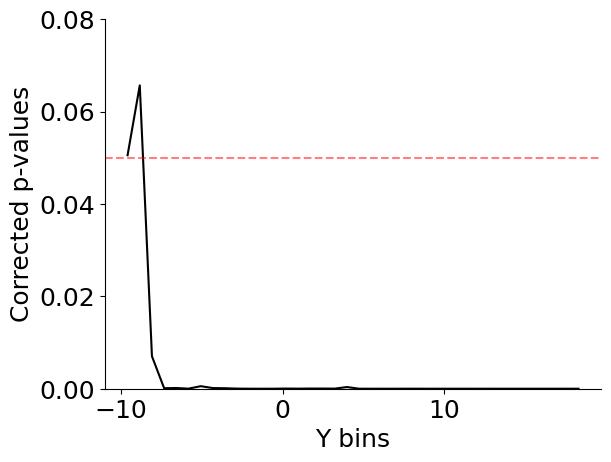

In [267]:
sns.lineplot(data=p_value_df, x="segment", y="p_value_corr", c="black")
plt.axhline(0.05, linestyle="dashed", color="red", alpha=0.5)
plt.xlabel("Y bins")
plt.ylabel("Corrected p-values")
plt.ylim(0,0.08)

# Mean trajcetory by mouse

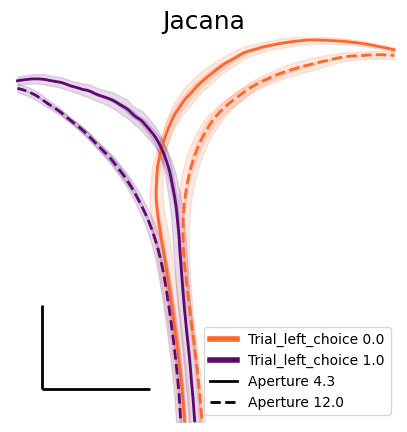

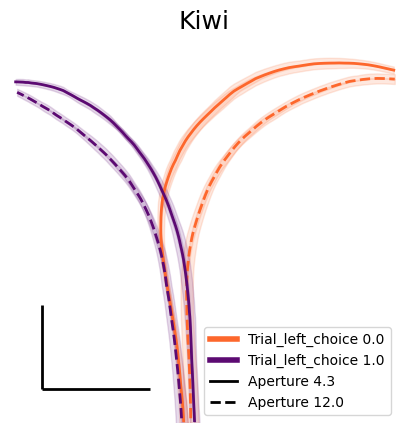

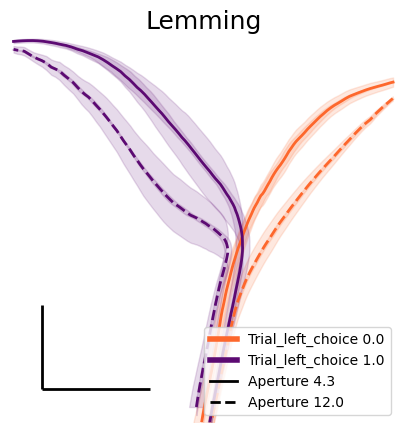

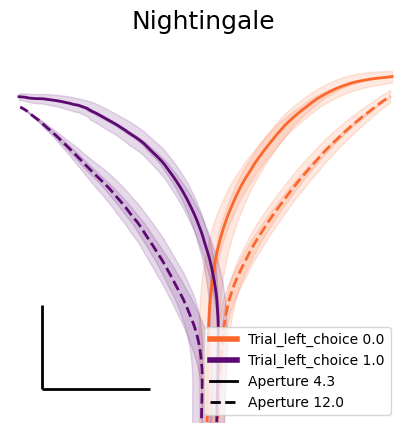

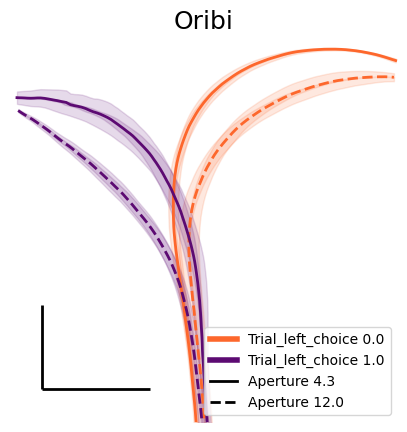

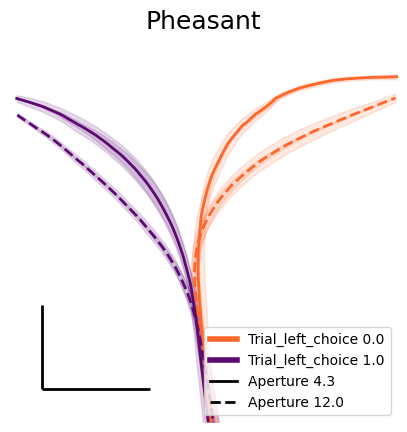

In [172]:
for m in xy_df.mouse_name.unique():
    dfp = xy_df [xy_df.mouse_name==m]
    # mean across sessions to get mouse mean and sem
    dfp = analysis.mean_xy_trajectory(dfp, index_columns= [ "mouse_name", "aperture", "trial_left_choice", "trial_length"])
    plotting.plot_mean_xy_trajectory(dfp, cmap = plotting.colors_choice [::-1], color_by="choice", style_by="aperture")
    plt.title(f"{m}")
    plt.savefig(f"Figure2_mean_trajectories_{m}.svg", transparent=True)

In [184]:
velocity_df = []
for m in mouse_list:
    print(m)
    velocity_df.append(pd.DataFrame((MeanVelocities() & f'dataset="{m}"').fetch(as_dict=True)[0]))
velocity_df = pd.concat(velocity_df)

Jacana_2024-08-13_1
Jacana_2024-08-14_1
Jacana_2024-08-15_1
Jacana_2024-08-16_1
Jacana_2024-08-19_1
Kiwi_2024-08-10_2
Kiwi_2024-08-11_4
Kiwi_2024-08-12_2
Kiwi_2024-08-13_1
Kiwi_2024-08-14_1
Lemming_2024-08-10_1
Lemming_2024-08-11_1
Lemming_2024-08-12_1
Lemming_2024-08-13_1
Nightingale_2024-08-10_1
Nightingale_2024-08-11_1
Nightingale_2024-08-12_1
Nightingale_2024-08-13_1
Nightingale_2024-08-14_1
Oribi_2024-08-16_1
Oribi_2024-08-19_1
Oribi_2024-08-20_1
Oribi_2024-08-21_1
Oribi_2024-08-22_1
Pheasant_2024-08-15_2
Pheasant_2024-08-16_1
Pheasant_2024-08-19_1
Pheasant_2024-08-20_1
Pheasant_2024-08-21_1


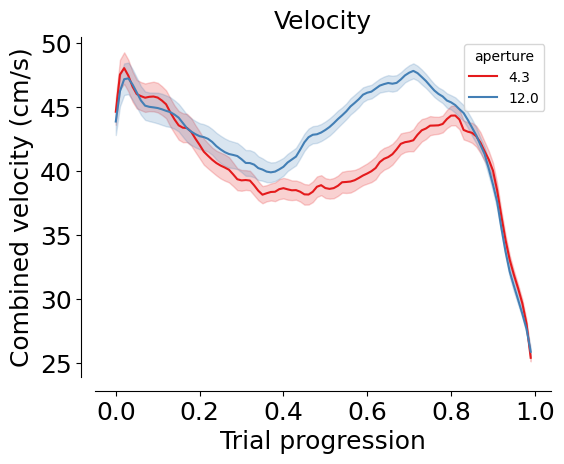

In [185]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax = ax

sns.lineplot(
    data=velocity_df,
    x="trial_length",
    y="velocity",
    palette=(
        plotting.colors_aperture[:2]
        if len(mean_mouse.aperture.unique()) == 2
        else plotting.colors_aperture[:2]
    ),
    hue="aperture",
    errorbar="se",
    ax=ax,
)
ax.set_title(f"Velocity")
sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Combined velocity (cm/s)")
plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "mean_velocity.svg", transparent=True)

In [186]:
print(
    AnovaRM(
        data=velocity_df,
        depvar="velocity",
        subject="dataset",
        within=["aperture", "trial_length"],
    ).fit()
)

                        Anova
                      F Value  Num DF   Den DF  Pr > F
------------------------------------------------------
aperture              50.9477  1.0000   28.0000 0.0000
trial_length          72.3124 99.0000 2772.0000 0.0000
aperture:trial_length 19.7750 99.0000 2772.0000 0.0000



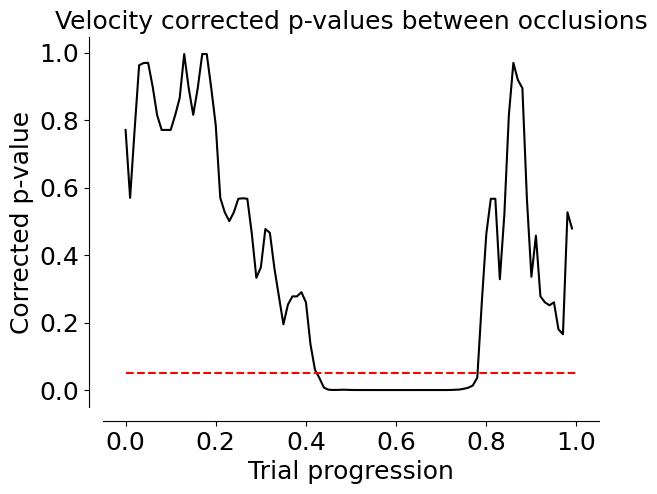

In [190]:
p_values = []
for i in velocity_df.trial_length.unique():
    section = velocity_df[velocity_df.trial_length == i]
    t = ttest_ind(
        section[section.aperture == section.aperture.unique()[0]].velocity,
        section[section.aperture == section.aperture.unique()[1]].velocity,
    )
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df = pd.concat(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

plt.plot(p_value_df.segment, p_value_df.p_value_corr, c="k")

plt.hlines(0.05, xmin=0, xmax=1, color="red", linestyle="dashed")

plt.xlabel("Trial progression")
plt.ylabel("Corrected p-value")
plt.title("Velocity corrected p-values between occlusions")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure2_velocity_pvalue.svg", transparent=True)

In [ ]:
# TODO This fecth call is a little slow, maybe we should add an optimal p table
optimal_df = []
for m in mouse_list:
    print(m)
    optimal_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch("dataset", "trial", "aperture", "optimal_p", as_dict=True)[0]))
optimal_df = pd.concat(optimal_df)

optimal_df =  optimal_df.groupby(["dataset", "mouse_name", "trial", "aperture"], as_index=False).mean()
optimal_df =  optimal_df.groupby(["dataset", "mouse_name", "aperture"], as_index=False).mean()

Jacana_2024-08-13_1
Jacana_2024-08-14_1
Jacana_2024-08-15_1
Jacana_2024-08-16_1
Jacana_2024-08-19_1
Kiwi_2024-08-10_2
Kiwi_2024-08-11_4
Kiwi_2024-08-12_2
Kiwi_2024-08-13_1
Kiwi_2024-08-14_1
Lemming_2024-08-10_1
Lemming_2024-08-11_1
Lemming_2024-08-12_1
Lemming_2024-08-13_1
Nightingale_2024-08-10_1
Nightingale_2024-08-11_1
Nightingale_2024-08-12_1
Nightingale_2024-08-13_1
Nightingale_2024-08-14_1
Oribi_2024-08-16_1
Oribi_2024-08-19_1
Oribi_2024-08-20_1
Oribi_2024-08-21_1
Oribi_2024-08-22_1
Pheasant_2024-08-15_2
Pheasant_2024-08-16_1
Pheasant_2024-08-19_1
Pheasant_2024-08-20_1
Pheasant_2024-08-21_1


2025-06-06 12:23:44,929::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-06 12:23:44,929::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-06 12:23:44,935::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-06 12:23:44,935::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-06 12:23:45,014::INFO::category.py::Using categorical un

12.0-4.3: TtestResult(statistic=-6.8197360298695395, pvalue=2.0786664891642388e-07, df=28)


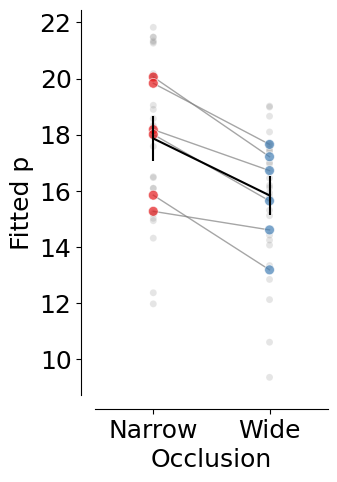

In [192]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
optimal_df["mouse_name"] = optimal_df.dataset.str.split("_").str [0]
counts = (
    optimal_df
    .groupby(["mouse_name", "dataset", "aperture"], as_index=False)
    .optimal_p.mean()
)

counts["count"] = counts["optimal_p"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax,
    per_mouse=True,
    cmap=plotting.colors_aperture[0:2],
)
ax.invert_xaxis()

ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_xlabel("Occlusion")
plt.legend([], [], frameon=False)
ax.set_ylabel("Fitted p")

sns.despine(offset=10)

plt.savefig(save_fig_path + "figure2_fitted_p.svg", transparent=True)

for i in counts.aperture.unique():
    for j in counts.aperture.unique():
        if i < j:
            stat = stats.ttest_rel(
                counts[counts["aperture"] == i]["optimal_p"],
                counts[counts["aperture"] == j]["optimal_p"],
            )
            print(f"{i}-{j}: {stat}")

# below this point is the old code - leaving here for reference

In [ ]:
# add sessions to groups table for easily pulling sessions
dual_occuder = [
    {"dataset": "Nightingale_2024-08-14_1"},
    {"dataset": "Nightingale_2024-08-13_1"},
    {"dataset": "Nightingale_2024-08-12_1"},
    {"dataset": "Nightingale_2024-08-11_1"},
    {"dataset": "Nightingale_2024-08-10_1"},
    {"dataset": "Lemming_2024-08-13_1"},
    {"dataset": "Lemming_2024-08-12_1"},
    {"dataset": "Lemming_2024-08-11_1"},
    {"dataset": "Lemming_2024-08-10_1"},
    {"dataset": "Jacana_2024-08-13_1"},
    {"dataset": "Jacana_2024-08-14_1"},
    {"dataset": "Jacana_2024-08-15_1"},
    {"dataset": "Jacana_2024-08-16_1"},
    {"dataset": "Jacana_2024-08-19_1"},
    {"dataset": "Kiwi_2024-08-10_2"},
    {"dataset": "Kiwi_2024-08-11_4"},
    {"dataset": "Kiwi_2024-08-12_2"},
    {"dataset": "Kiwi_2024-08-13_1"},
    {"dataset": "Kiwi_2024-08-14_1"},
    {"dataset": "Oribi_2024-08-16_1"},
    {"dataset": "Oribi_2024-08-19_1"},
    {"dataset": "Oribi_2024-08-20_1"},
    {"dataset": "Oribi_2024-08-21_1"},
    {"dataset": "Oribi_2024-08-22_1"},
    {"dataset": "Pheasant_2024-08-15_2"},
    {"dataset": "Pheasant_2024-08-16_1"},
    {"dataset": "Pheasant_2024-08-20_1"},
    {"dataset": "Pheasant_2024-08-21_1"},
    {"dataset": "pheasant_2024-08-19_1"}
]

dual_occuder = dual_occuder + (Dataset() * DataFrame() & 'dataset LIKE "%31728%" AND session_label = "ar_discrim_occluders"').fetch("dataset",as_dict=True)
dual_occuder = dual_occuder + (Dataset() * DataFrame() & 'dataset LIKE "%31726%" AND session_label = "ar_discrim_occluders"').fetch("dataset",as_dict=True)
print(len(dual_occuder))

In [ ]:
def get_all_in_list(data_set_list, training_stage):
    print(training_stage)
    big_df = []

    for d in data_set_list:
        split_d = d["dataset"].split("_")
        print(split_d)

        offline_kinematics_df = dlc.OfflineKinematics().get_data(
            key=d,
            columns=["head_center_x", "head_center_y", "heading_dir", "head_angle"],
        )
        df = base_analysis.DataFrame().get_data(
            key=d,
            columns=[
                "dataset",
                "trial",
                "aperture",
                "trial_right_choice",
                "trial_left_choice",
                "velocity",
                "velocity_x",
                "velocity_y",
                "reward",
                "norm_y",
                "iti",
                "x",
                "y",
                "trial_init_x",
                "trial_init_y",
                "trial_tortuosity",
                "trial_duration",
            ],
        )
        df["trial_rewarded"] = base_analysis.DataFrame().get_rewarded(key=d)

        df = df.join(offline_kinematics_df)

        df["mouse_name"] = split_d[0]
        df["date"] = split_d[1]
        df["attempt"] = split_d[2]
        df["training_stage"] = training_stage

        big_df.append(df)

    big_df = pd.concat(big_df).reset_index()
    big_df["session_increment"] = np.array(big_df.groupby("dataset").ngroup() + 1)
    big_df = big_df.infer_objects()

    return big_df.reset_index(drop=True)

In [9]:
dual_occuder = [
    {"dataset": d}
    for d in (vr4mice.Groups() * vr4mice.Labels & 'label="dual_occluder_paper"').fetch(
        "dataset"
    )
]

In [ ]:
dfs = []
dual = (vr4mice.Dataset() & f'session_label = "ar_discrim_occluders"') & (
    vr4mice.Collab() & "idx=3"
)
dual_list = [{"dataset": x["dataset"]} for x in dual]
if {"dataset": "J731_2024-12-11_1"} in dual_list:
    dual_list.remove({"dataset": "J731_2024-12-11_1"})
if {"dataset": "J731_2024-12-12_1"} in dual_list:
    dual_list.remove({"dataset": "J731_2024-12-12_1"})
if {"dataset": "J731_2024-12-13_1"} in dual_list:
    dual_list.remove({"dataset": "J731_2024-12-13_1"})
print(dual_list)
big_df = get_all_in_list(data_set_list=dual_list, training_stage="ar_discrim_occluders")

In [34]:
tolias = pd.read_pickle("big_df_contrast_tolias_new.pkl")
neil_df = pd.read_pickle("big_df_contrast_dual_niell.pkl")
mathis =  pd.read_pickle("dual_occluder_mathis_lab_all_sessions.pkl")

big_df = pd.concat([tolias, neil_df, mathis]).reset_index(drop=True)
#big_df, reward_table = utils.dual_occluder_inclusion_criteria(big_df, return_excluded=False)

In [41]:
vr4mice.Groups() & "dataset = 'Lemming_2024-08-09_1'"

dataset,idx
Lemming_2024-08-09_1,2


In [26]:
big_df = pd.concat([tolias, neil_df, mathis]).reset_index(drop=True)

In [ ]:
mean_df = big_df.groupby(["dataset","mouse_name", "aperture"], as_index=False)[["trial_rewarded"]].mean()

In [28]:
big_df, reward_table = utils.dual_occluder_inclusion_criteria(mean_df, return_excluded=False)

Excluded datasets:  ['31728_2025-03-05_1' '31728_2025-03-06_1' 'J729_2024-11-29_1'
 'J731_2024-12-04_1' 'J731_2024-12-06_1']


In [ ]:
# ITI removal
big_df = big_df [big_df.iti == 0.0].copy()
j_shaped = analysis.get_jshaped_trials(big_df, threshold_duration=5, threshold_tortuosity=5).copy()
interpolated_j_shaped = utils.interpolate(df=j_shaped, interpolation_columns=["dataset", "mouse_name", "attempt", "trial"], value_columns=["aperture", "trial_left_choice", "trial_step", "x", "y"],n_points=100)
interpolated_j_shaped["trial_step"] = interpolated_j_shaped.groupby(
        ["dataset", "mouse_name", "trial"], as_index=False
    ).trial.cumcount()

interpolated_j_shaped["trial_length"] = (
        interpolated_j_shaped["trial_step"] / 100
    )
interpolated_j_shaped["flip_one_side"] = interpolated_j_shaped["trial_left_choice"].replace([0, 1], [1, -1])
interpolated_j_shaped["x_flipped"] = interpolated_j_shaped.x * interpolated_j_shaped.flip_one_side

2025-05-19 08:31:30,665::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-19 08:31:30,665::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-19 08:31:30,683::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-19 08:31:30,683::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-19 08:31:30,770::INFO::category.py::Using categorical un

12.0-4.3: TtestResult(statistic=6.1051172985231545, pvalue=2.3642560366762376e-07, df=44)
              mean       sem
aperture                    
12.0      0.860820  0.010085
4.3       0.761279  0.014309


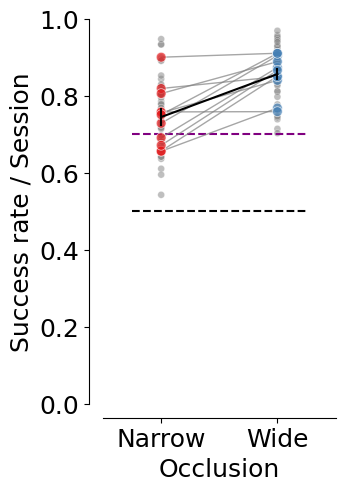

In [ ]:
# Success rate per mouse
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
plotting.plot_rate(
    df=big_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
)

ax.hlines(
    0.7,
    xmin=-0.25,
    xmax=len(big_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="purple",
)
ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(big_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)
plt.ylim(0, 1.0)
plt.xlim(-0.5, 1.5)
ax.set_ylabel("Success rate / Session")
ax.set_xlabel("Occlusion")
ax.set_xticks([0, 1], ["Narrow", "Wide"])
sns.despine(offset=10)
plt.legend([], [], frameon=False)
plt.savefig(save_fig_path + "31728_trial_reward.svg", transparent=True)

2025-05-19 08:31:35,564::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-19 08:31:35,564::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-19 08:31:35,570::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-19 08:31:35,570::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-19 08:31:35,753::INFO::category.py::Using categorical un

wide occlusion mean:  0.5029370939998659 std:  0.03935574676056645
narrow occlusion mean:  0.49706290600013414 std:  0.039355746760566454


TtestResult(statistic=0.49503513836610064, pvalue=0.6230384538492006, df=44)

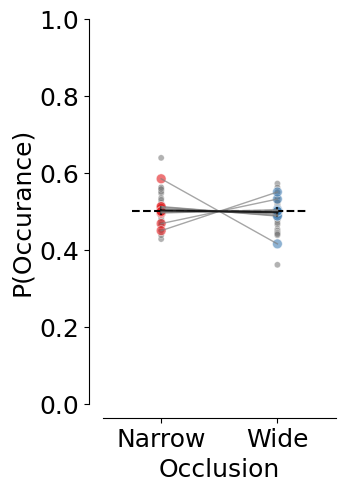

In [ ]:
# Occurance of the different conditions
counts = (
    mean_df.groupby(["dataset", "mouse_name", "aperture"])
    .trial.nunique()
    .reset_index(name="trial_count")
)
total_trials = (
    mean_df.groupby("dataset").trial.nunique().reset_index(name="total_trials")
)

counts = counts.merge(total_trials, on="dataset")
counts["probability"] = counts["trial_count"] / counts["total_trials"]
counts.sort_values("aperture", inplace=True)
counts["aperture"] = counts.aperture.astype("str")

fig, ax = plt.subplots(1, 1, figsize=(3, 5))

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    units="mouse_name",
    estimator=None,
    ax=ax,
    color="grey",
    alpha=0.7,
    linewidth=1,
    zorder=3,
)

sns.scatterplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    hue="aperture",
    ax=ax,
    palette=plotting.colors_aperture,
    alpha=0.6,
    s=50,
    zorder=2,
)

sns.scatterplot(
    data=counts,
    x="aperture",
    y="probability",
    hue="aperture",
    ax=ax,
    palette=["grey"] * counts["dataset"].nunique(),
    alpha=0.6,
    zorder=1,
    s=20,
)

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    ax=ax,
    color="black",
    err_style="bars",
    errorbar="se",
    alpha=0.8,
    zorder=4,
)

ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(big_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

plt.ylim(0, 1)
plt.xlim(-0.5, 1.5)
plt.xticks([0, 1], ["Narrow", "Wide"])

plt.xlabel("Occlusion")
plt.ylabel("P(Occurance)")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(save_fig_path + "figure2_dual_occluder_trial_number.svg", transparent=True)

counts = counts.pivot(index="dataset", columns=["aperture"], values=["probability"])
print(
    "wide occlusion mean: ",
    np.mean(np.array(counts["probability"]["12.0"])),
    "std: ",
    np.std(np.array(counts["probability"]["12.0"])),
)
print(
    "narrow occlusion mean: ",
    np.mean(np.array(counts["probability"]["4.3"])),
    "std: ",
    np.std(np.array(counts["probability"]["4.3"])),
)
ttest_rel(
    np.array(counts["probability"]["12.0"]), np.array(counts["probability"]["4.3"])
)

2025-04-03 13:19:58,006::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-03 13:19:58,006::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-03 13:19:58,013::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-03 13:19:58,013::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-03 13:19:58,087::INFO::category.py::Using categorical un

12.0-4.3: TtestResult(statistic=-1.3463087056376606, pvalue=0.18509818259216526, df=44)
              mean       sem
aperture                    
12.0      0.528409  0.018017
4.3       0.571509  0.021902


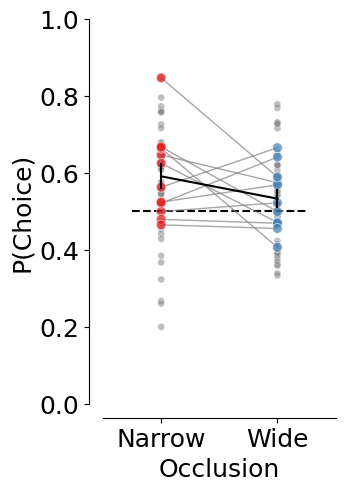

In [14]:
# Trial probability of left choice
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
plotting.plot_rate(
    df=big_df,
    label_x="trial_left_choice",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
)

ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_xlabel("Occlusion")
ax.set_ylim(0, 1)
plt.legend([], [], frameon=False)
plt.ylabel("P(Choice)")
ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(big_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

sns.despine(offset=10)

#plt.savefig(save_fig_path + "figure2_dual_occluder_choice_proba.svg", transparent=True)

## Mean trajectory plots

In [16]:
# Filter the data - no iti and only J_shaped trials
big_df = big_df[big_df.iti == 0.0]
j_shaped = analysis.get_jshaped_trials(big_df)
j_shaped = utils.create_bins(
    data=j_shaped.copy(), spatial_ybins=[6.75, 18, 20], label="y"
)
# [6.75, 20, 30]
mean_mouse = (
    j_shaped.groupby(
        ["dataset", "mouse_name", "trial_left_choice", "aperture", "bin_centers"], as_index=False
    )
    .mean(numeric_only=True)
    .copy()
)

median_mouse = (
    j_shaped.groupby(
        ["dataset", "mouse_name", "trial_left_choice", "aperture", "bin_centers"], as_index=False
    )
    .median(numeric_only=True)
    .copy()
)



31726_2025-03-18_1

31726_2025-03-19_1

31726_2025-03-20_1

31726_2025-03-21_1

31728_2025-03-07_1

31728_2025-03-20_1

31728_2025-03-21_1

J729_2024-11-30_1

J729_2024-12-01_1

J729_2024-12-02_1

J729_2024-12-03_1

J729_2024-12-04_1

J729_2024-12-10_1

J731_2024-12-05_1

J731_2024-12-09_1

Jacana_2024-08-13_1

Jacana_2024-08-14_1

Jacana_2024-08-15_1

Jacana_2024-08-16_1

Jacana_2024-08-19_1

Kiwi_2024-08-10_2


/tmp/ipykernel_1550283/3265962598.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 1, figsize=(5, 5))



Kiwi_2024-08-11_4

Kiwi_2024-08-12_2

Kiwi_2024-08-13_1

Kiwi_2024-08-14_1

Lemming_2024-08-09_1

Lemming_2024-08-10_1


KeyboardInterrupt: 

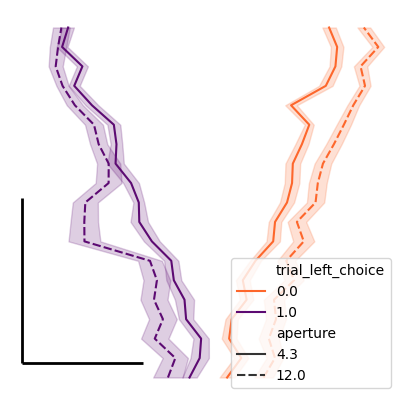

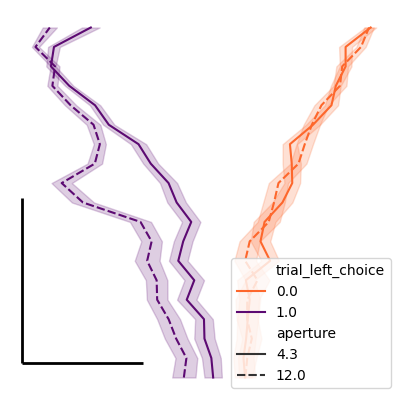

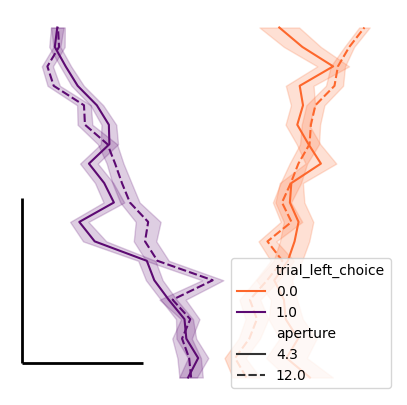

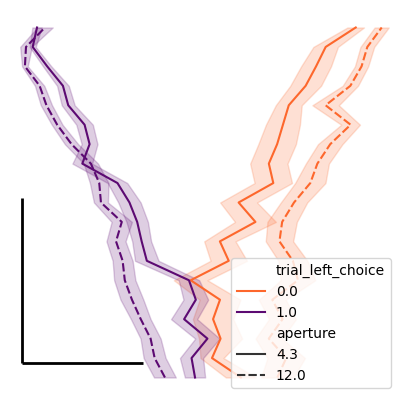

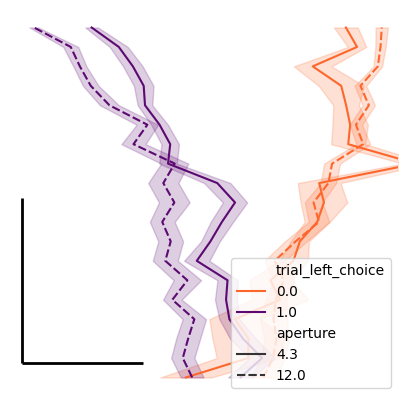

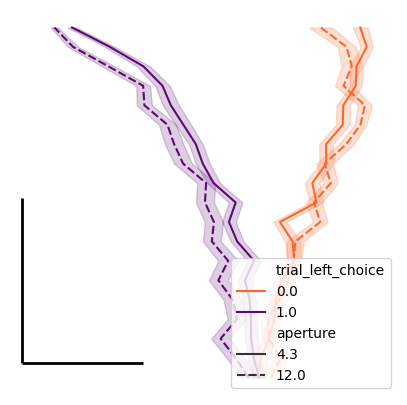

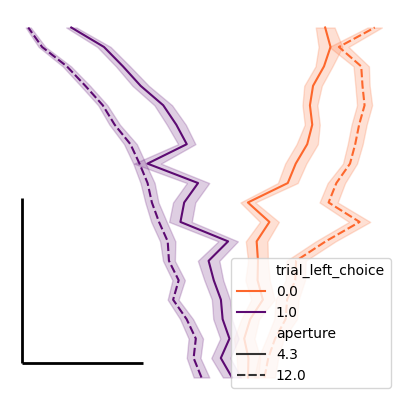

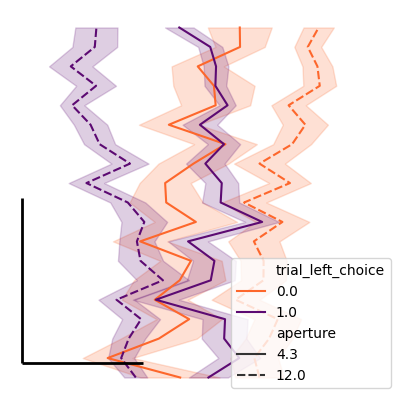

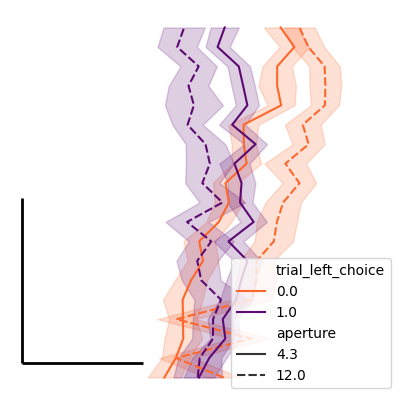

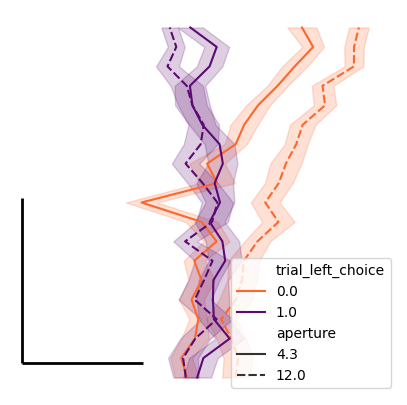

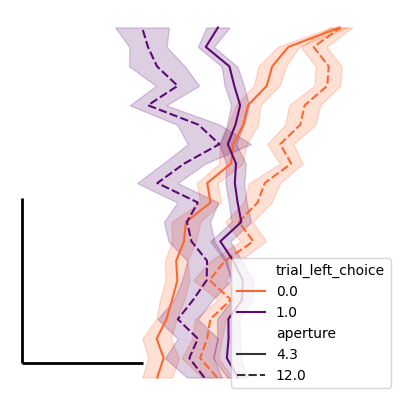

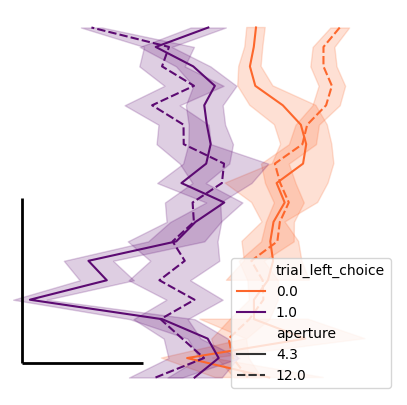

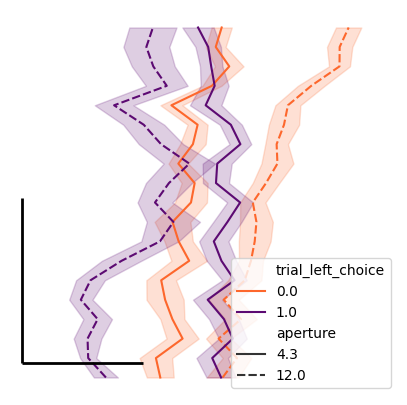

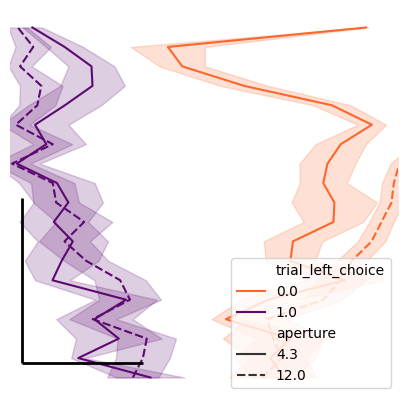

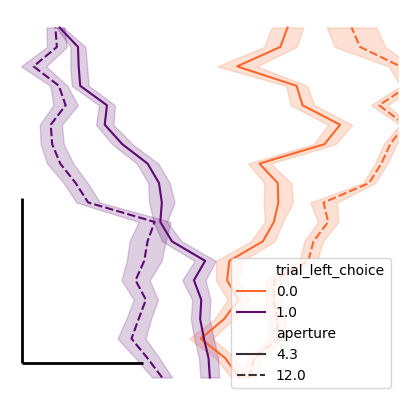

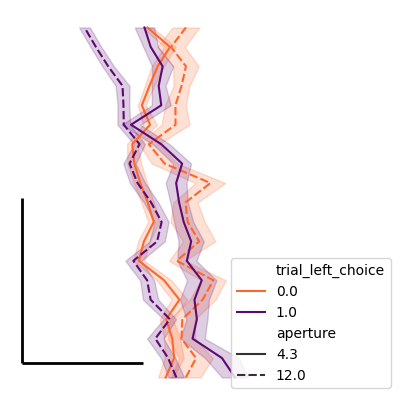

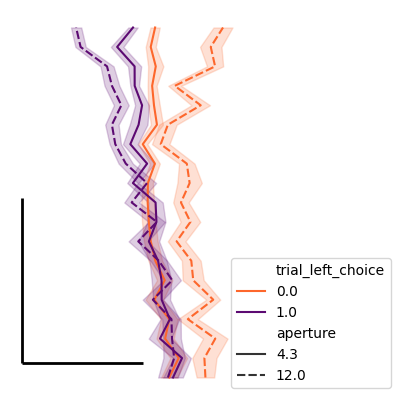

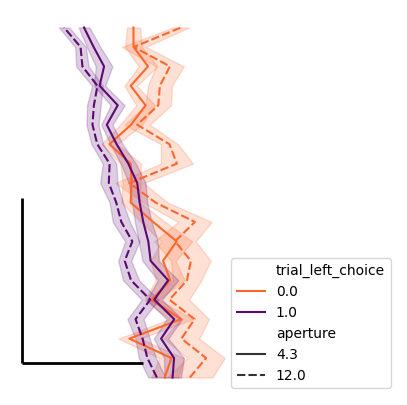

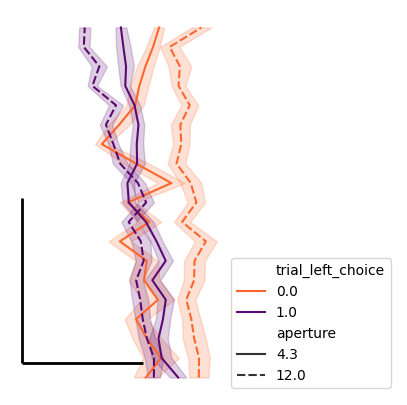

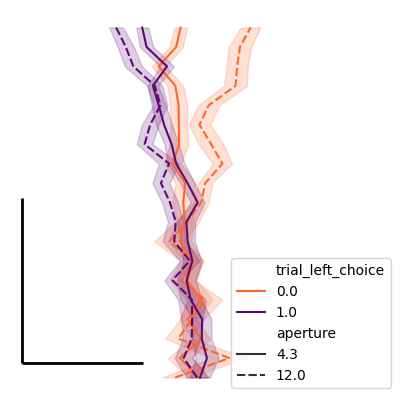

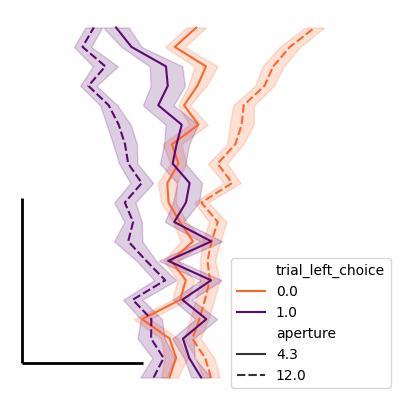

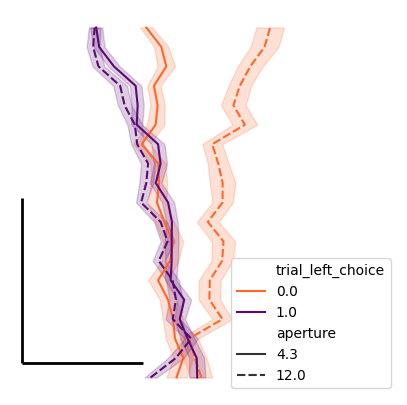

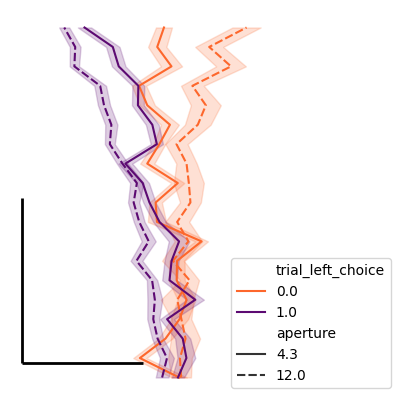

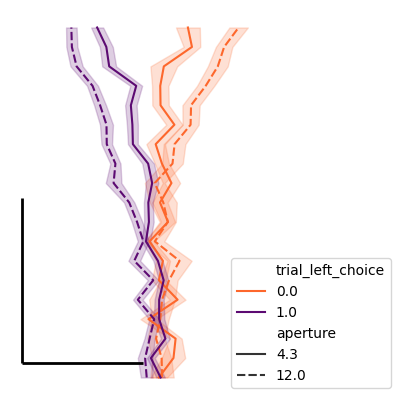

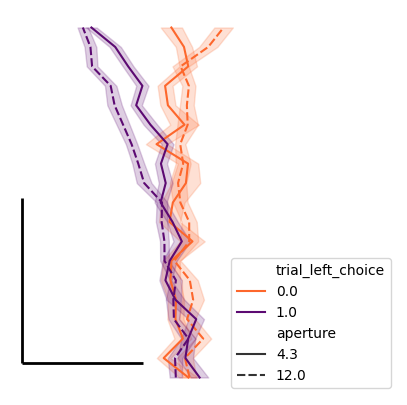

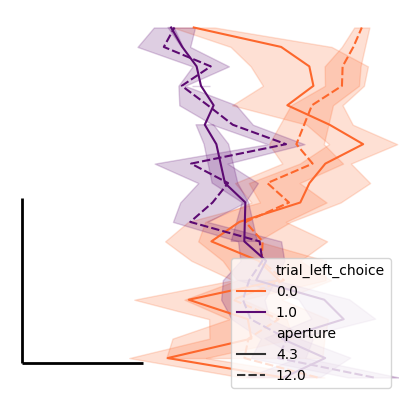

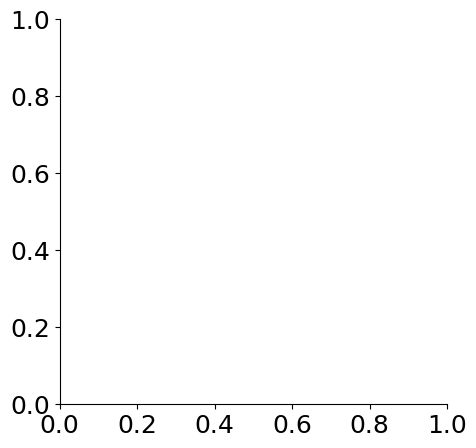

In [17]:

for m in mean_mouse.dataset.unique():
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    mouse_dataset =  m
    print(mouse_dataset)
    j_shaped = analysis.get_jshaped_trials(big_df, threshold_duration=5, threshold_tortuosity=5)
    j_shaped = utils.create_bins(
        data=j_shaped.copy(), spatial_ybins=[6.75, 18, 20], label="y"
    )
    plotting.lineplot_flip_axis(
        data=j_shaped [j_shaped.dataset ==  mouse_dataset],
        x="bin_centers",
        y="x",
        hue="trial_left_choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
        palette=plotting.colors_choice[::-1]
        if len(mean_mouse.aperture.unique()) == 2
        else "viridis",
        style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "choice",
        errorbar="se",
        ax=ax,
    )
    plt.ylabel("y position")
    plt.xlabel("x position")
    plt.xlim(-16, 16)
    plt.vlines(x=-15, ymin=7.5, ymax=12.5, color="black", linewidth=2)
    plt.hlines(y=7.5, xmin=-15, xmax=-5, color="black", linewidth=2)
    plt.axis("off")
    ax.legend(loc="lower right")
    print()
    plt.savefig(save_fig_path + f"{m}_mean_trajectory_ss.svg", transparent=True)

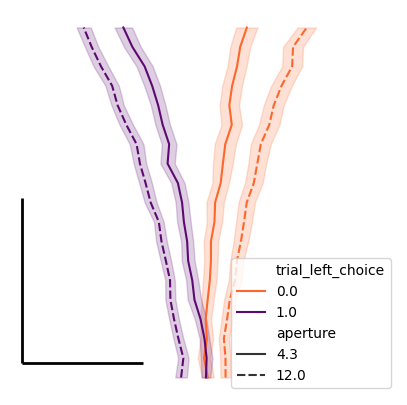

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plotting.lineplot_flip_axis(
    data=mean_mouse,
    x="bin_centers",
    y="x",
    hue="trial_left_choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
    palette=plotting.colors_choice[::-1]
    if len(mean_mouse.aperture.unique()) == 2
    else "viridis",
    style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "choice",
    errorbar="se",
    ax=ax,
)
plt.ylabel("y position")
plt.xlabel("x position")
plt.xlim(-16, 16)
plt.vlines(x=-15, ymin=7.5, ymax=12.5, color="black", linewidth=2)
plt.hlines(y=7.5, xmin=-15, xmax=-5, color="black", linewidth=2)
plt.axis("off")
ax.legend(loc="lower right")
plt.savefig(save_fig_path + "figure2_mean_trajectory_tolias.svg", transparent=True)

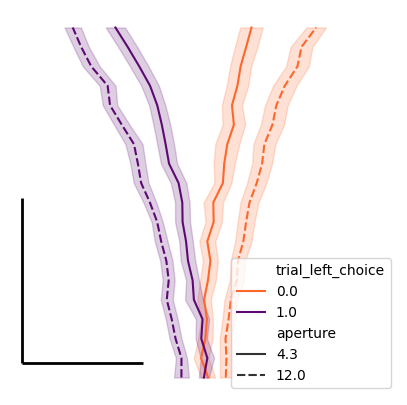

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plotting.lineplot_flip_axis(
    data=median_mouse,
    x="bin_centers",
    y="x",
    hue="trial_left_choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
    palette=plotting.colors_choice[::-1]
    if len(mean_mouse.aperture.unique()) == 2
    else "viridis",
    style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "choice",
    errorbar="se",
    ax=ax,
)
plt.ylabel("y position")
plt.xlabel("x position")
plt.xlim(-16, 16)
plt.vlines(x=-15, ymin=7.5, ymax=12.5, color="black", linewidth=2)
plt.hlines(y=7.5, xmin=-15, xmax=-5, color="black", linewidth=2)
plt.axis("off")
ax.legend(loc="lower right")
plt.savefig(save_fig_path + "figure2_median_trajectory_tolias.svg", transparent=True)

In [21]:
j_shaped["flip_one_side"] = j_shaped["trial_left_choice"].replace([0, 1], [1, -1])
j_shaped["x_flipped"] = j_shaped["x"] * j_shaped.flip_one_side
mean_mouse = (
    j_shaped.groupby(["dataset", "aperture", "bin_centers"], as_index=False)
    .mean(numeric_only=True)
    .copy()
)

In [22]:
print(
    AnovaRM(
        data=mean_mouse,
        depvar="x_flipped",
        subject="dataset",
        within=["aperture", "bin_centers"],
    ).fit()
)

                        Anova
                     F Value   Num DF  Den DF  Pr > F
-----------------------------------------------------
aperture              74.9880  1.0000  44.0000 0.0000
bin_centers          131.4648 18.0000 792.0000 0.0000
aperture:bin_centers   9.6886 18.0000 792.0000 0.0000



**Interpretation**

Since all p-values are very small (0.0000), we can conclude that both aperture and bin_centers significantly influence x_flipped, and their interaction is also significant. This means that the effect of aperture on x_flipped depends on bin_centers.

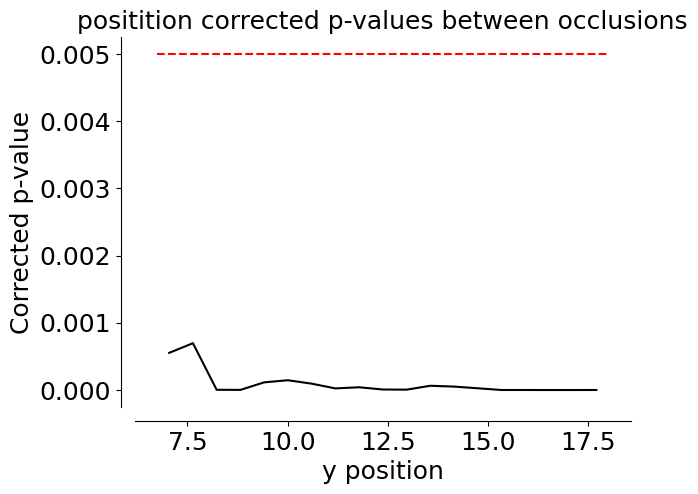

In [23]:
p_values = []
for i in mean_mouse.bin_centers.unique():
    section = mean_mouse[mean_mouse.bin_centers == i]
    t = ttest_ind(
        section[section.aperture == section.aperture.unique()[0]].x_flipped,
        section[section.aperture == section.aperture.unique()[1]].x_flipped,
    )
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df = pd.concat(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

plt.plot(p_value_df.segment, p_value_df.p_value_corr, c="k")

plt.hlines(0.005, xmin=6.75, xmax=18, color="red", linestyle="dashed")

plt.xlabel("y position")
plt.ylabel("Corrected p-value")
plt.title("positition corrected p-values between occlusions")

sns.despine(offset=10)
#plt.savefig(save_fig_path + "figure2_position_pvalue.svg", transparent=True)

In [24]:
from scipy.stats import ttest_rel

# Get unique bin centers
bin_centers = mean_mouse["bin_centers"].unique()
aperture_levels = mean_mouse["aperture"].unique()

if len(aperture_levels) != 2:
    raise ValueError("This test assumes exactly 2 aperture levels.")

# Loop through each bin center and compare apertures
results = []
for bin_center in bin_centers:
    subset = mean_mouse[mean_mouse["bin_centers"] == bin_center]

    x1 = subset[subset["aperture"] == aperture_levels[0]]["x_flipped"]
    x2 = subset[subset["aperture"] == aperture_levels[1]]["x_flipped"]

    if len(x1) == len(x2):  # Ensure paired samples
        t_stat, p_val = ttest_rel(x1, x2)
        results.append((bin_center, t_stat, p_val))
    else:
        print(f"Skipping bin center {bin_center} due to mismatched sample sizes.")

# Print results
for bin_center, t_stat, p_val in results:
    print(f"Bin Center {bin_center}: t = {t_stat:.3f}, p = {p_val:.5f}")

Bin Center 7.045999999999999: t = -3.610, p = 0.00078
Bin Center 7.638: t = -4.382, p = 0.00007
Bin Center 8.23: t = -5.447, p = 0.00000
Bin Center 8.822: t = -6.286, p = 0.00000
Bin Center 9.4145: t = -4.985, p = 0.00001
Bin Center 10.007000000000001: t = -4.772, p = 0.00002
Bin Center 10.599: t = -5.405, p = 0.00000
Bin Center 11.190999999999999: t = -6.936, p = 0.00000
Bin Center 11.783000000000001: t = -6.773, p = 0.00000
Bin Center 12.375: t = -7.639, p = 0.00000
Bin Center 12.966999999999999: t = -7.096, p = 0.00000
Bin Center 13.559000000000001: t = -7.061, p = 0.00000
Bin Center 14.151: t = -5.827, p = 0.00000
Bin Center 14.742999999999999: t = -7.360, p = 0.00000
Bin Center 15.3355: t = -9.076, p = 0.00000
Bin Center 15.928: t = -8.439, p = 0.00000
Bin Center 16.52: t = -8.669, p = 0.00000
Bin Center 17.112000000000002: t = -8.858, p = 0.00000
Bin Center 17.704: t = -8.959, p = 0.00000


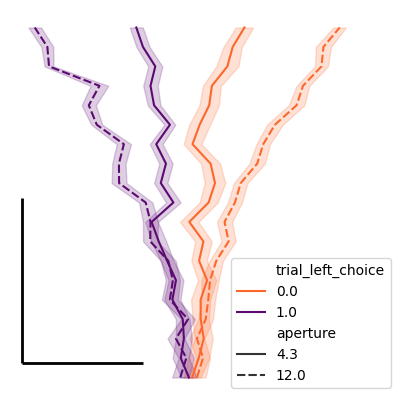

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plotting.lineplot_flip_axis(
    data=j_shaped[j_shaped.dataset == "Pheasant_2024-08-15_2"],
    x="bin_centers",
    y="x",
    hue="trial_left_choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
    palette=plotting.colors_choice[::-1]
    if len(mean_mouse.aperture.unique()) == 2
    else "viridis",
    style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "choice",
    errorbar="se",
    ax=ax,
)
plt.ylabel("y position")
plt.xlabel("x position")
plt.xlim(-16, 16)
plt.vlines(x=-15, ymin=7.5, ymax=12.5, color="black", linewidth=2)
plt.hlines(y=7.5, xmin=-15, xmax=-5, color="black", linewidth=2)
plt.axis("off")

ax.legend(loc="lower right")
plt.savefig(
    save_fig_path + "figure2_example_session_mean_trajectory.svg", transparent=True
)

In [25]:
interpolated_j_shaped = utils.interpolate_j_shaped(
    big_df, box_df, n_points=100
)  # 100 to run anova

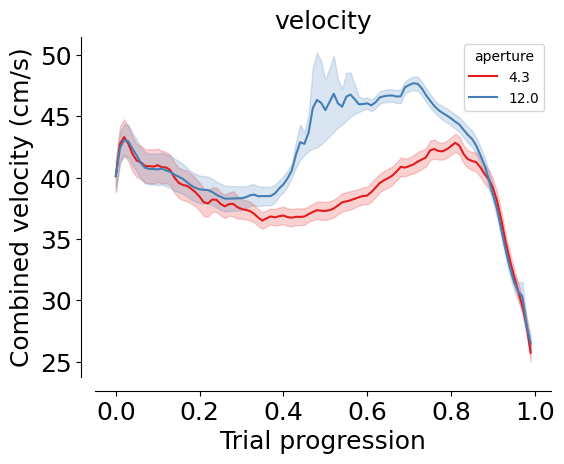

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax = ax
mean_mouse = interpolated_j_shaped.groupby(
    ["dataset", "aperture", "trial_length"], as_index=False
).mean(numeric_only=True)

label = "velocity"
sns.lineplot(
    data=mean_mouse,
    x="trial_length",
    y="velocity",
    palette=(
        plotting.colors_aperture[:2]
        if len(mean_mouse.aperture.unique()) == 2
        else plotting.colors_aperture[:2]
    ),
    hue="aperture",
    errorbar="se",
    ax=ax,
)
ax.set_title(f"{label}")
sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Combined velocity (cm/s)")
plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "mean_velocity.svg", transparent=True)

In [28]:
print(
    AnovaRM(
        data=mean_mouse,
        depvar="velocity",
        subject="dataset",
        within=["aperture", "trial_length"],
    ).fit()
)

                        Anova
                      F Value  Num DF   Den DF  Pr > F
------------------------------------------------------
aperture              52.3249  1.0000   44.0000 0.0000
trial_length          26.6757 99.0000 4356.0000 0.0000
aperture:trial_length  9.8423 99.0000 4356.0000 0.0000



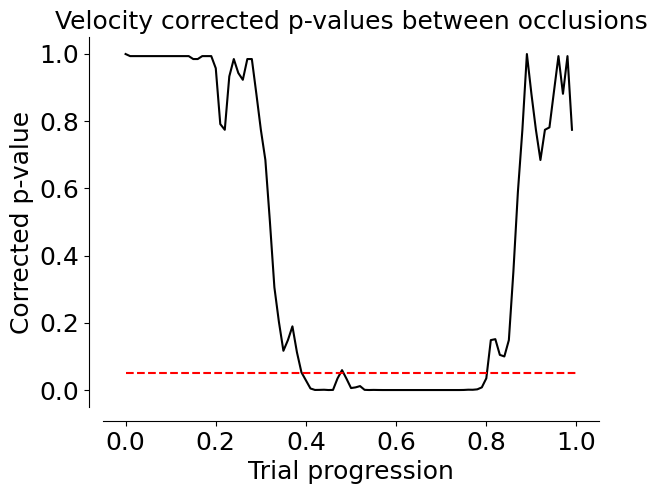

In [29]:
p_values = []
for i in mean_mouse.trial_length.unique():
    section = mean_mouse[mean_mouse.trial_length == i]
    t = ttest_ind(
        section[section.aperture == section.aperture.unique()[0]].velocity,
        section[section.aperture == section.aperture.unique()[1]].velocity,
    )
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df = pd.concat(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

plt.plot(p_value_df.segment, p_value_df.p_value_corr, c="k")

plt.hlines(0.05, xmin=0, xmax=1, color="red", linestyle="dashed")

plt.xlabel("Trial progression")
plt.ylabel("Corrected p-value")
plt.title("Velocity corrected p-values between occlusions")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure2_velocity_pvalue.svg", transparent=True)

## Optimal p of an L-p curve

In [30]:
big_df["optimal_p"] = analysis.get_optimal_p(big_df)
j_shaped = analysis.get_jshaped_trials(big_df)

2025-04-03 13:27:52,616::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-03 13:27:52,616::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-03 13:27:52,622::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-03 13:27:52,622::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-03 13:27:52,722::INFO::category.py::Using categorical un

12.0-4.3: TtestResult(statistic=-3.7617407515843837, pvalue=0.0004951260819040018, df=44)


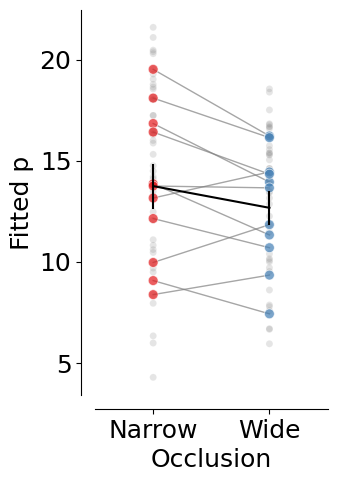

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))

counts = (
    j_shaped[j_shaped.trial_rewarded == 1]
    .groupby(["mouse_name", "dataset", "aperture"], as_index=False)
    .optimal_p.mean()
)

counts["count"] = counts["optimal_p"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax,
    per_mouse=True,
    cmap=plotting.colors_aperture[0:2],
)
ax.invert_xaxis()

ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_xlabel("Occlusion")
plt.legend([], [], frameon=False)
ax.set_ylabel("Fitted p")

sns.despine(offset=10)

plt.savefig(save_fig_path + "figure2_fitted_p.svg", transparent=True)

for i in counts.aperture.unique():
    for j in counts.aperture.unique():
        if i < j:
            stat = stats.ttest_rel(
                counts[counts["aperture"] == i]["optimal_p"],
                counts[counts["aperture"] == j]["optimal_p"],
            )
            print(f"{i}-{j}: {stat}")